In [1]:
# IMPORTS
from rldb.utils import *
import torch
import numpy as np
from typing import Iterable, List, Tuple, Optional
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

/coc/flash7/rpunamiya6/miniconda3/envs/everse/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load dataset
root = "/coc/cedarp-dxu345-0/datasets/egoverse/eve_fold_clothes_diverse/lerobot_6dof"
repo_id = "rpuns/robot"

robot_dataset = RLDBDataset(repo_id=repo_id, root=root, local_files_only=True, mode="total")

robot_data_schematic = DataSchematic(schematic_dict={
    "eve_bimanual":{
        "actions_cartesian":{
            "key_type": "action_keys",
            "lerobot_key": "actions_cartesian",
            "prestack": True
        }
    }}, viz_img_key= {"eve_bimanual" : "front_img_1"}, norm_mode= "zscore"
)


robot_data_schematic.infer_shapes_from_batch(robot_dataset[0])
robot_data_schematic.infer_norm_from_dataset(robot_dataset)


Returning existing local_dir `/coc/cedarp-dxu345-0/datasets/egoverse/eve_fold_clothes_diverse/lerobot_6dof` as remote repo cannot be accessed in `snapshot_download` (None).
Returning existing local_dir `/coc/cedarp-dxu345-0/datasets/egoverse/eve_fold_clothes_diverse/lerobot_6dof` as remote repo cannot be accessed in `snapshot_download` (None).
Returning existing local_dir `/coc/cedarp-dxu345-0/datasets/egoverse/eve_fold_clothes_diverse/lerobot_6dof` as remote repo cannot be accessed in `snapshot_download` (None).


In [3]:
# Load human (in-domain) dataset
root_human_indomain = "/coc/cedarp-dxu345-0/datasets/egoverse/fold_clothes_inDomain/lerobot_6dof"
repo_id_human_indomain = "rpuns/human_indomain"

human_dataset_indomain = RLDBDataset(
    repo_id=repo_id_human_indomain,
    root=root_human_indomain,
    local_files_only=True,
    mode="total",
)

# Data schematic for human (in-domain)
human_indomain_data_schematic = DataSchematic(
    schematic_dict={
        "aria_bimanual": {
            "actions_cartesian": {
                "key_type": "action_keys",
                "lerobot_key": "actions_cartesian",
                "prestack": True,  # keep same behavior as robot
            }
        }
    },
    viz_img_key={"aria_bimanual": "front_img_1"},
    norm_mode="zscore",
)

# Infer shapes + normalization from the dataset
human_indomain_data_schematic.infer_shapes_from_batch(human_dataset_indomain[0])
human_indomain_data_schematic.infer_norm_from_dataset(human_dataset_indomain)



Returning existing local_dir `/coc/cedarp-dxu345-0/datasets/egoverse/fold_clothes_inDomain/lerobot_6dof` as remote repo cannot be accessed in `snapshot_download` (None).
Returning existing local_dir `/coc/cedarp-dxu345-0/datasets/egoverse/fold_clothes_inDomain/lerobot_6dof` as remote repo cannot be accessed in `snapshot_download` (None).
Returning existing local_dir `/coc/cedarp-dxu345-0/datasets/egoverse/fold_clothes_inDomain/lerobot_6dof` as remote repo cannot be accessed in `snapshot_download` (None).


In [4]:
# Load human (Egoverse) dataset combining multiple labs
human_dataset_egoverse = MultiRLDBDataset(
    datasets={
        "rl2_lab": FolderRLDBDataset(
            folder_path="/coc/cedarp-dxu345-0/datasets/egoverse/fold_clothes",
            embodiment="aria_bimanual",
            mode="total",
            local_files_only=True,
        ),
        "wang_lab": FolderRLDBDataset(
            folder_path="/coc/cedarp-dxu345-0/datasets/egoverse/fold_clothes_wang",
            embodiment="aria_bimanual",
            mode="total",
            local_files_only=True,
        ),
        "eth_lab": FolderRLDBDataset(
            folder_path="/coc/cedarp-dxu345-0/datasets/egoverse/fold_clothes_eth",
            embodiment="aria_bimanual",
            mode="total",
            local_files_only=True,
        ),
    },
    embodiment="aria_bimanual",
)

# Data schematic for human (Egoverse)
human_egoverse_data_schematic = DataSchematic(
    schematic_dict={
        "aria_bimanual": {
            "actions_cartesian": {
                "key_type": "action_keys",
                "lerobot_key": "actions_cartesian",
                "prestack": True,
            }
        }
    },
    viz_img_key={"aria_bimanual": "front_img_1"},
    norm_mode="zscore",
)

# Infer shapes and normalization from the combined dataset
human_egoverse_data_schematic.infer_shapes_from_batch(human_dataset_egoverse[0])
human_egoverse_data_schematic.infer_norm_from_dataset(human_dataset_egoverse)


Returning existing local_dir `/coc/cedarp-dxu345-0/datasets/egoverse/fold_clothes/lerobot_6dof` as remote repo cannot be accessed in `snapshot_download` (None).


Returning existing local_dir `/coc/cedarp-dxu345-0/datasets/egoverse/fold_clothes/lerobot_6dof` as remote repo cannot be accessed in `snapshot_download` (None).
Returning existing local_dir `/coc/cedarp-dxu345-0/datasets/egoverse/fold_clothes/lerobot_6dof` as remote repo cannot be accessed in `snapshot_download` (None).
Skipping rawAria: missing meta/info.json
Skipped 1 datasets: ['rawAria']
Returning existing local_dir `/coc/cedarp-dxu345-0/datasets/egoverse/fold_clothes_wang/fold_cloth_wang_scene_10_recording_1_processed` as remote repo cannot be accessed in `snapshot_download` (None).
Returning existing local_dir `/coc/cedarp-dxu345-0/datasets/egoverse/fold_clothes_wang/fold_cloth_wang_scene_10_recording_1_processed` as remote repo cannot be accessed in `snapshot_download` (None).
Returning existing local_dir `/coc/cedarp-dxu345-0/datasets/egoverse/fold_clothes_wang/fold_cloth_wang_scene_10_recording_1_processed` as remote repo cannot be accessed in `snapshot_download` (None).
Retur

In [5]:

PINK = "#F4A7B9"
BLUE = "#8CB4FF"
BLUE_EGOVERSE = "#000000"
COORD_LABELS = ("x_left", "y_left", "z_left", "x_right", "y_right", "z_right")


def _to_numpy(value: object) -> np.ndarray:
    """Convert tensors or lists to a 2D NumPy array."""
    if isinstance(value, torch.Tensor):
        value = value.detach().cpu().numpy()
    value = np.asarray(value)
    if value.ndim == 1:
        value = value[None, :]
    elif value.ndim > 2:
        last_dim = value.shape[-1]
        value = value.reshape(-1, last_dim)
    return value


In [6]:
def _collect_actions(dataset,
                     key: str,
                     dims: Optional[Iterable[int]],
                     max_samples: Optional[int],
                     stride: int) -> np.ndarray:
    """
    Concatenate samples along leading dims; supports (..., D).
    If dims is provided, select those columns in the last dim.
    Returns (N, len(dims)) float32.
    """
    dims = tuple(dims) if dims is not None else None
    buf: List[np.ndarray] = []
    gathered = 0
    for idx in range(0, len(dataset), stride):
        arr = _to_numpy(dataset[idx][key])         # (..., D)
        arr = _flatten_keep_last(arr)              # (N_i, D)
        if dims is not None:
            if arr.shape[-1] < max(dims) + 1:
                raise ValueError(f"Requested dims {dims} but action shape is {arr.shape}.")
            arr = arr[:, dims]                     # (N_i, len(dims))
        buf.append(arr)
        gathered += arr.shape[0]
        if max_samples is not None and gathered >= max_samples:
            break
    if not buf:
        raise RuntimeError("No action samples collected; verify dataset paths and keys.")
    out = np.concatenate(buf, axis=0)
    if max_samples is not None and out.shape[0] > max_samples:
        out = out[:max_samples]
    return out.astype(np.float32)


def _density_curve(samples: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """Return x/y points for a smooth density curve with a fallback for low variance data."""
    samples = samples.astype(np.float64)
    if samples.size == 0:
        raise ValueError("Received empty sample array for density estimation.")
    stdev = np.std(samples)
    pad = max(stdev * 3.0, 1e-3)
    domain = np.linspace(samples.min() - pad, samples.max() + pad, 512)
    if stdev < 1e-6:
        center = samples.mean()
        return domain, np.exp(-0.5 * ((domain - center) / (pad + 1e-6)) ** 2)
    kde = gaussian_kde(samples)
    return domain, kde(domain)


def _infer_xyz_dims(sample_action_dim: int):
    if sample_action_dim == 14:
        # robot: (xyz, ypr, grip, xyz, ypr, grip)
        return (0, 1, 2), (7, 8, 9)
    elif sample_action_dim == 12:
        # human: (xyz, ypr, xyz, ypr)
        return (0, 1, 2), (6, 7, 8)
    else:
        raise ValueError(f"Unexpected action dim={sample_action_dim}. Expected 12 (human) or 14 (robot).")

def _peek_action_dim(dataset, actions_key: str) -> int:
    first = _to_numpy(dataset[0][actions_key])
    first = _flatten_keep_last(first)  # ensure (..., D) -> (N, D)
    return int(first.shape[-1])

def _gather_xyz_unnorm(dataset, actions_key: str, max_samples: Optional[int], stride: int):
    dim = _peek_action_dim(dataset, actions_key)
    left_xyz, right_xyz = _infer_xyz_dims(dim)
    left = _collect_actions(dataset, actions_key, left_xyz, max_samples, stride)   # (N,3)
    right = _collect_actions(dataset, actions_key, right_xyz, max_samples, stride) # (N,3)
    return left, right


def _gather_xyz_norm(dataset,
                     actions_key: str,
                     max_samples: int | None,
                     stride: int,
                     data_schematic,
                     embodiment: str):
    """
    Collect FULL actions (..., D), normalize with data_schematic, then slice XYZ dims.
    Returns (left_xyz, right_xyz) each shaped (N, 3).
    """
    # Peek D and pick dims (strict 12 for human, 14 for robot)
    dim = _peek_action_dim(dataset, actions_key)
    left_xyz, right_xyz = _infer_xyz_dims(dim)

    # 1) Collect FULL vectors (N, D) unnormalized
    full = _collect_actions(dataset, actions_key, dims=None, max_samples=max_samples, stride=stride)  # (N, D)
    
    D = full.shape[-1]
    N = full.shape[0]
    B = N // 100
    full = full[: B * 100].reshape(B, 100, D)

    # 2) Normalize via DataSchematic per embodiment
    emb_id = get_embodiment_id(embodiment)
    norm_full = data_schematic.normalize_data(
        {actions_key: torch.from_numpy(full).float()},
        emb_id,
    )[actions_key].detach().cpu().numpy()  # (N, D)
    
    norm_full = norm_full.reshape(-1, D)

    # 3) Slice left/right xyz
    left = norm_full[:, left_xyz]   # (N, 3)
    right = norm_full[:, right_xyz] # (N, 3)
    return left, right


def _plot_one(coord_arrays: List[np.ndarray],
              labels: List[str],
              colors: List[str],
              title: str,
              linewidth: float = 2.0):
    plt.figure(figsize=(7, 5))
    for arr, lab, col in zip(coord_arrays, labels, colors):
        x, y = _density_curve(arr)
        plt.plot(x, y, label=lab, linewidth=linewidth, color=col)
    plt.title(title)
    plt.xlabel("meters")   # adjust if needed
    plt.ylabel("density")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()
    

def _flatten_keep_last(arr: np.ndarray) -> np.ndarray:
    """Reshape (..., D) -> (N, D) by flattening all leading dims."""
    arr = np.asarray(arr)
    if arr.ndim < 2:
        raise ValueError(f"Expected at least 2D array (..., D), got shape {arr.shape}")
    return arr.reshape(-1, arr.shape[-1])


In [7]:
def plot_all_coords_kde_unnorm(
    robot_dataset,
    human_dataset_indomain,
    human_dataset_egoverse,
    actions_key: str = "actions_cartesian",
    max_samples: Optional[int] = 250_000,
    stride: int = 10,
):
    """
    2×3 grid (rows: left/right arms, cols: x/y/z), overlaying:
      - Robot (PINK), Human (In-domain) (BLUE), Human (Egoverse) (BLUE_EGOVERSE).
    """
    robot_left, robot_right = _gather_xyz_unnorm(robot_dataset, actions_key, max_samples, stride)
    human_in_left, human_in_right = _gather_xyz_unnorm(human_dataset_indomain, actions_key, max_samples, stride)
    human_eg_left, human_eg_right = _gather_xyz_unnorm(human_dataset_egoverse, actions_key, max_samples, stride)

    names = ["Robot", "Human (In-domain)", "Human (Egoverse)"]
    cols = [PINK, BLUE, BLUE_EGOVERSE]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)
    fig.suptitle("Unnormalized KDEs of Cartesian Actions", fontsize=16)

    def plot_kde(ax, data_list, title):
        for vals, lab, col in zip(data_list, names, cols):
            x, y = _density_curve(vals)
            ax.plot(x, y, label=lab, linewidth=2.0, color=col)
        ax.set_title(title)
        ax.set_xlabel("meters")
        ax.set_ylabel("density")

    # Left arm (row 0)
    plot_kde(axes[0, 0], [robot_left[:, 0], human_in_left[:, 0], human_eg_left[:, 0]], "x_left")
    plot_kde(axes[0, 1], [robot_left[:, 1], human_in_left[:, 1], human_eg_left[:, 1]], "y_left")
    plot_kde(axes[0, 2], [robot_left[:, 2], human_in_left[:, 2], human_eg_left[:, 2]], "z_left")

    # Right arm (row 1)
    plot_kde(axes[1, 0], [robot_right[:, 0], human_in_right[:, 0], human_eg_right[:, 0]], "x_right")
    plot_kde(axes[1, 1], [robot_right[:, 1], human_in_right[:, 1], human_eg_right[:, 1]], "y_right")
    plot_kde(axes[1, 2], [robot_right[:, 2], human_in_right[:, 2], human_eg_right[:, 2]], "z_right")

    # Legend on the right
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", frameon=False)
    plt.tight_layout(rect=[0, 0, 0.93, 0.95])
    plt.show()


In [8]:
def plot_all_coords_kde_norm(
    robot_dataset,
    human_dataset_indomain,
    human_dataset_egoverse,
    robot_data_schematic,
    human_indomain_data_schematic,
    human_egoverse_data_schematic,
    actions_key: str = "actions_cartesian",
    max_samples: Optional[int] = 250_000,
    stride: int = 10,
):
    """
    2×3 grid (rows: left/right arms, cols: x/y/z), overlaying:
      - Robot (PINK), Human (In-domain) (BLUE), Human (Egoverse) (BLUE_EGOVERSE).
    """
    robot_left, robot_right = _gather_xyz_norm(robot_dataset, actions_key, max_samples, stride, robot_data_schematic, "eve_bimanual")
    human_in_left, human_in_right = _gather_xyz_norm(human_dataset_indomain, actions_key, max_samples, stride, human_indomain_data_schematic, "aria_bimanual")
    human_eg_left, human_eg_right = _gather_xyz_norm(human_dataset_egoverse, actions_key, max_samples, stride, human_egoverse_data_schematic, "aria_bimanual")

    names = ["Robot", "Human (In-domain)", "Human (Egoverse)"]
    cols = [PINK, BLUE, BLUE_EGOVERSE]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)
    fig.suptitle("Normalized KDEs of Cartesian Actions", fontsize=16)

    def plot_kde(ax, data_list, title):
        for vals, lab, col in zip(data_list, names, cols):
            x, y = _density_curve(vals)
            ax.plot(x, y, label=lab, linewidth=2.0, color=col)
        ax.set_title(title)
        ax.set_xlabel("meters")
        ax.set_ylabel("density")

    # Left arm (row 0)
    plot_kde(axes[0, 0], [robot_left[:, 0], human_in_left[:, 0], human_eg_left[:, 0]], "x_left")
    plot_kde(axes[0, 1], [robot_left[:, 1], human_in_left[:, 1], human_eg_left[:, 1]], "y_left")
    plot_kde(axes[0, 2], [robot_left[:, 2], human_in_left[:, 2], human_eg_left[:, 2]], "z_left")

    # Right arm (row 1)
    plot_kde(axes[1, 0], [robot_right[:, 0], human_in_right[:, 0], human_eg_right[:, 0]], "x_right")
    plot_kde(axes[1, 1], [robot_right[:, 1], human_in_right[:, 1], human_eg_right[:, 1]], "y_right")
    plot_kde(axes[1, 2], [robot_right[:, 2], human_in_right[:, 2], human_eg_right[:, 2]], "z_right")

    # Legend on the right
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", frameon=False)
    plt.tight_layout(rect=[0, 0, 0.93, 0.95])
    plt.show()


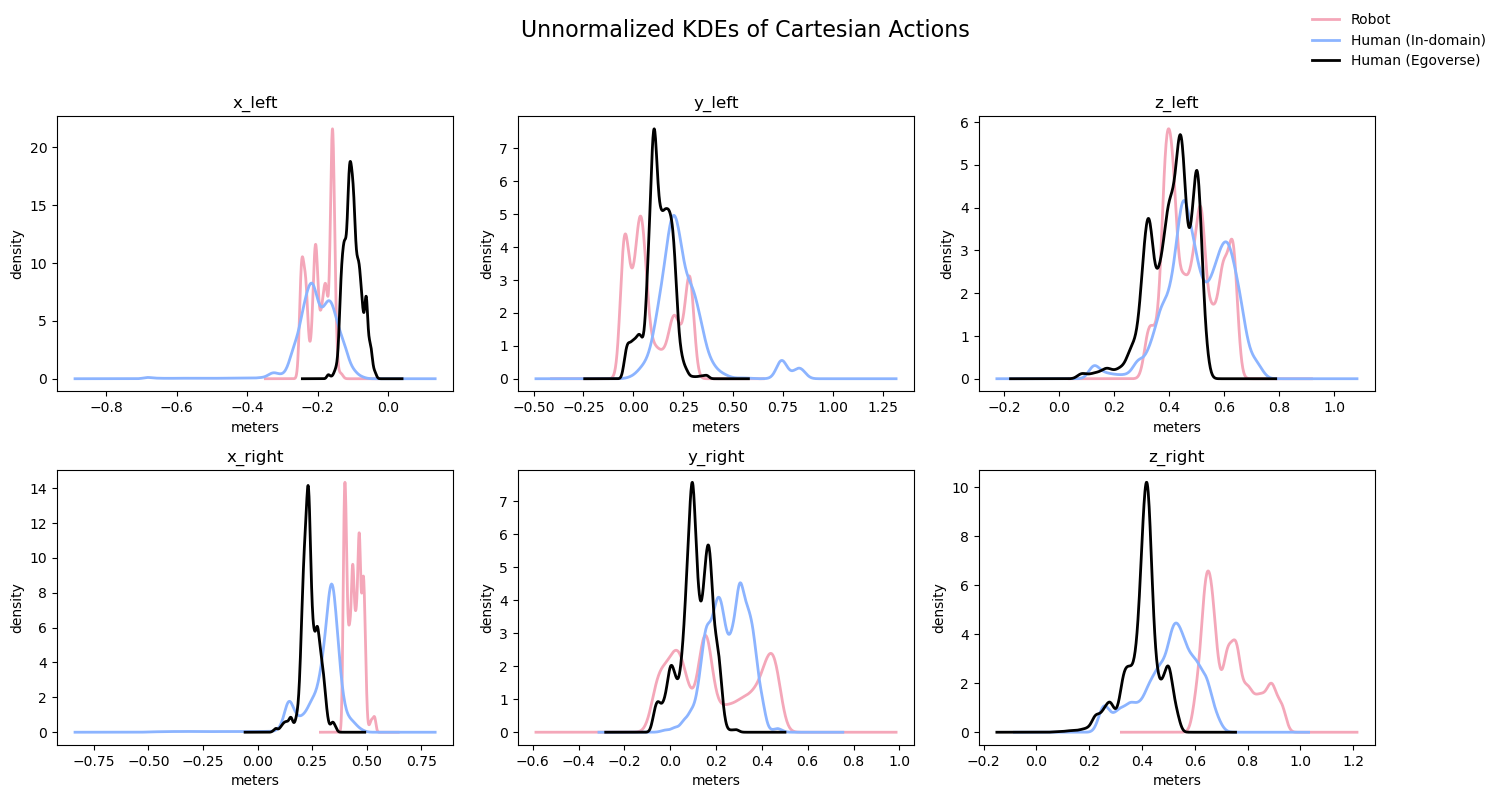

In [9]:
plot_all_coords_kde_unnorm(
    robot_dataset,
    human_dataset_indomain,
    human_dataset_egoverse,
    actions_key="actions_cartesian",
    max_samples=10_000,
    stride=5
)

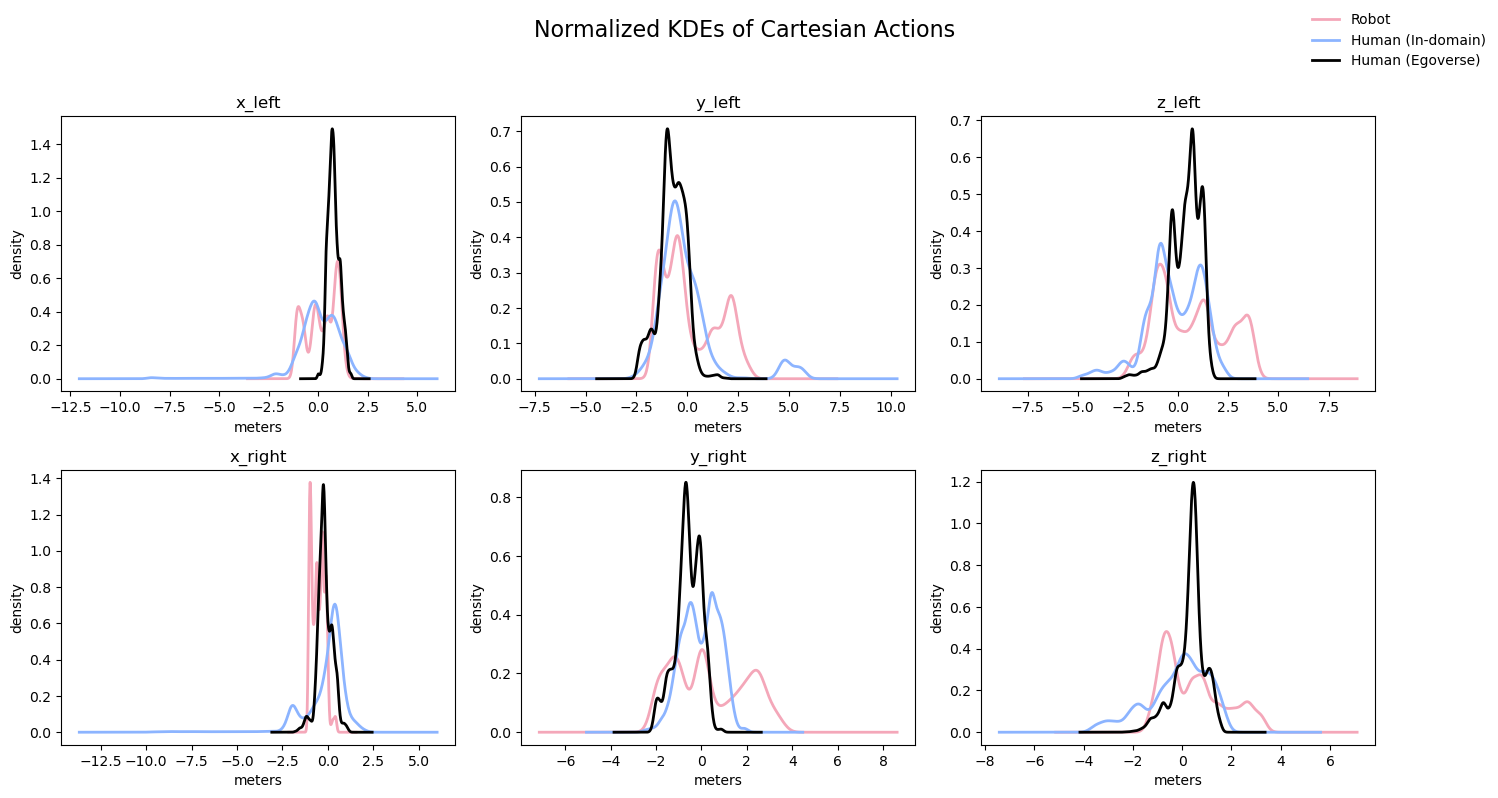

In [10]:
plot_all_coords_kde_norm(
    robot_dataset,
    human_dataset_indomain,
    human_dataset_egoverse,
    robot_data_schematic,            # ✅ schematic
    human_indomain_data_schematic,   # ✅ schematic
    human_egoverse_data_schematic,   # ✅ schematic
    actions_key="actions_cartesian",
    max_samples=10_000,
    stride=5
)